## Methode STIT de Klatt et Lotz


Persistence of asymptotic variance under transport: \
from hyperfluctuation to stealthy hyperuniformity \

cf Page 6 du papier:
https://arxiv.org/pdf/2605.22803


 STIT tessellations = STable with respect to ITerations

In [ ]:
import blue_sampler as blue
import numpy as np
import matplotlib.pyplot as plt
from blue_sampler.viz import show_polygons, show_clusters

In [3]:
def centroids(x):
    """
    x is a batch of quadrilaters of the shape (batch, 4, 2)
    we just compute barycenter for each tesselsrilateral
    """
    return x.mean(axis = 1)

def solve_moment(x, p):
    """
    one can also sample hyperuniform points by solving a moment equation,
    solving moment equality to all orders between 0 and p-1
    to strenghten hyperunformity. This is done by blue.from_geometry wich internaly
    solve the moment equation
    """
    return blue.from_geometry(x, gtype = "polygons", p = p)


## fair STIT allow to sample 1 million tessels in a matter of seconds
Here we show only the first tesselation steps

In [4]:
tessels = blue.sample_tessels(N = 2**8)

In [21]:
import inspect
inspect.getfile(blue.sample_tessels)

'/opt/homebrew/lib/python3.10/site-packages/blue_sampler/api.py'

## Now we can sample points well distributed with respect to the tessels


Here we just sample points at the center of each tessel

(256, 2)


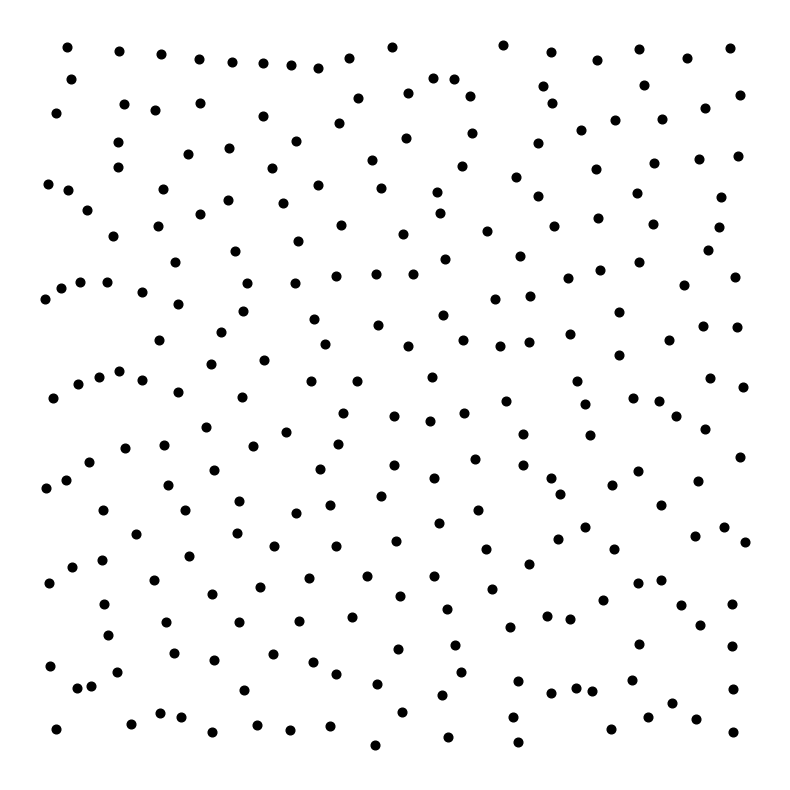

In [7]:
x_center = tessels.mean(axis = 1)
print(x_center.shape)
blue.plot(x_center)

In [13]:
import inspect
print(inspect.getsource(blue.from_geometry))

def from_geometry(
    geometry: NDArray,
    gtype: str,
    n: int = 6,
    p: int = 3,
    **kwargs
) -> NDArray:
    """
    Convert tessels or clusters into low-discrepancy point set.

    Each tessel or cluster is replaced by n points by solving a
    moment-matching problem (Levenberg-Marquardt) via `momentum_fit`.

    Parameters
    ----------
    geometry : ndarray
        Batch of tessels or clusters to convert.
        - gtype="polygons" : quadrilaterals of shape (N, 4, 2),
          e.g. the `quad` output of `sample_tessels`.
        - gtype="clusters" : point sets of shape (N, K, D),
          e.g. the output of `sample_clusters`, or the `atoms` output of
          `sample_tessels(..., return_atoms=True)`.
    gtype : {"polygons", "clusters"}
        Geometry type. "polygons" only supports D = 2.
    n : int, default 6
        Number of output points per tessel or cluster.
    p : int, default 3
        Maximum total moment order to match (centroid plus central moments
  

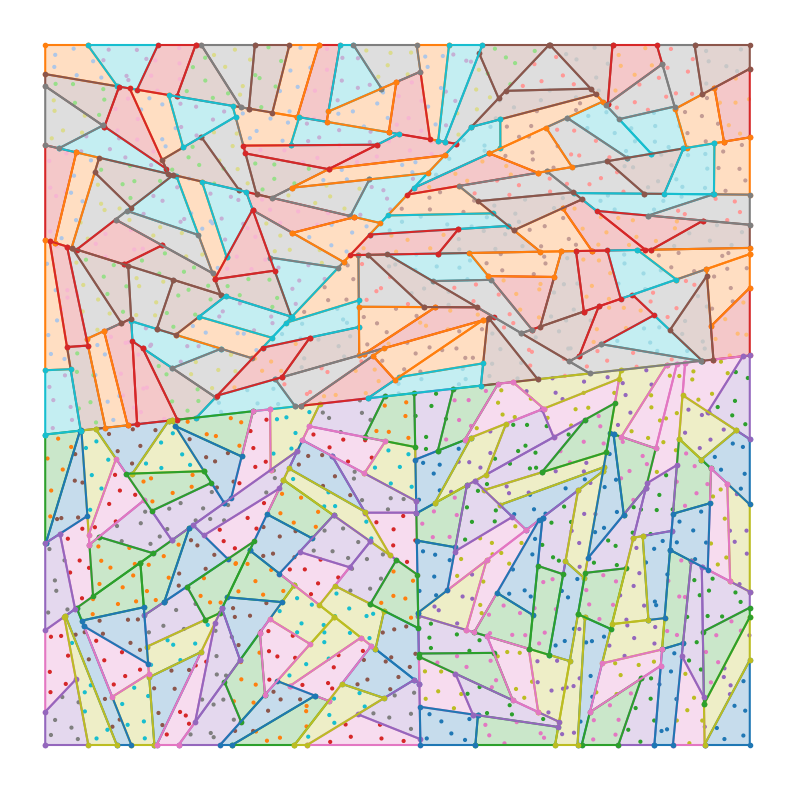

In [22]:


x_moment = blue.from_geometry(tessels, gtype = "polygons")
fig, ax = plt.subplots(figsize=(10, 10))

show_polygons(ax, tessels)
show_clusters(ax, x_moment)
plt.axis("off")
plt.show()

But one can also solve moment equation, eg solve moment up to order 2 (p = 3). slower but better results

(256, 6, 2)


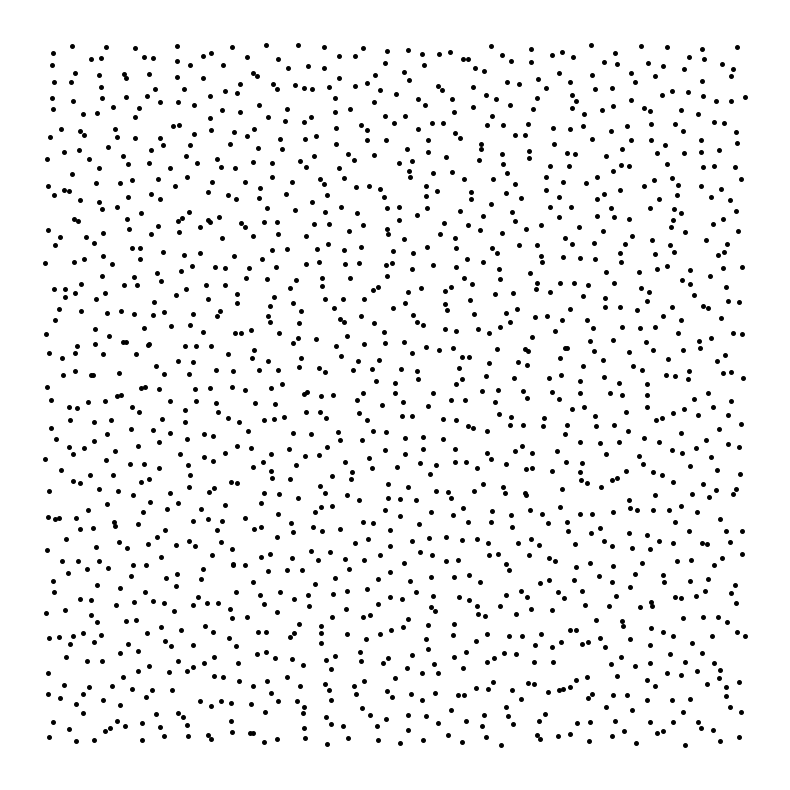

In [23]:
#x_moment = solve_moment(tessels, p = 3).reshape(-1, 2)
print(x_moment.shape)
blue.plot(x_moment)

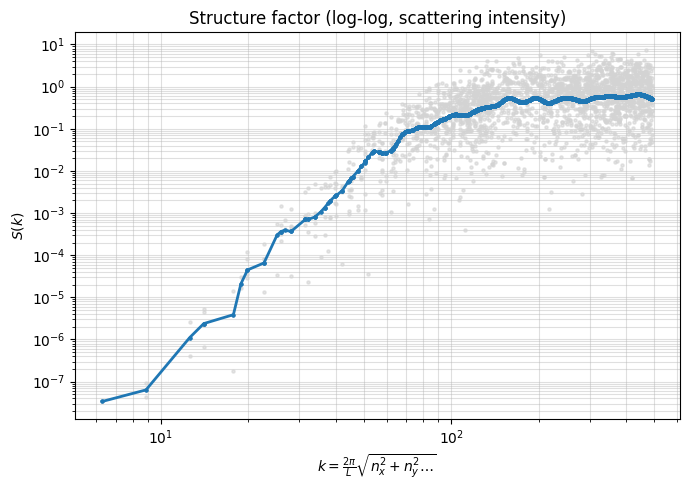

In [24]:
#blue.plot_structure_factor(x_center)
blue.plot_structure_factor(x_moment) #slower but better

## Tessels for adaptative sampling

In [8]:
from blue_sampler.datasets import generate_dataset

In [13]:
N = 1024*32
K = N * 100
targets = generate_dataset(dataset = "france", size = (K, 2), plot_data = False)
tessels, atoms = blue.sample_tessels(N =N, targets = targets, return_atoms = True)

source: squarenet.sampler from module squarenet
available datasets: {'realdata': ['barbara', 'lena', 'france', 'germany', 'everest'], 'synthetic': ['square', 'ball', 'ring', 'gaussian', 'spiky', 'holy', '4Dloop']}


## Here comes the magic

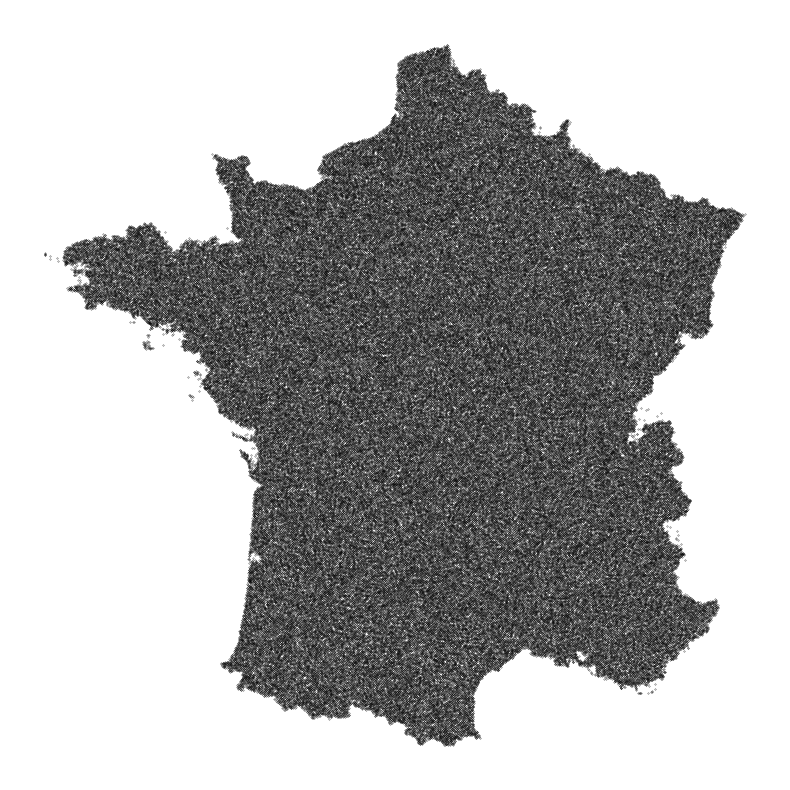

In [14]:
x = blue.from_geometry(atoms, gtype = "clusters", p = 3).reshape(-1, 2)
_ = blue.plot(x)